In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow #function imshow() para colab


In [2]:
arquivo = files.upload()

Saving rick-and-morty.jpg to rick-and-morty.jpg


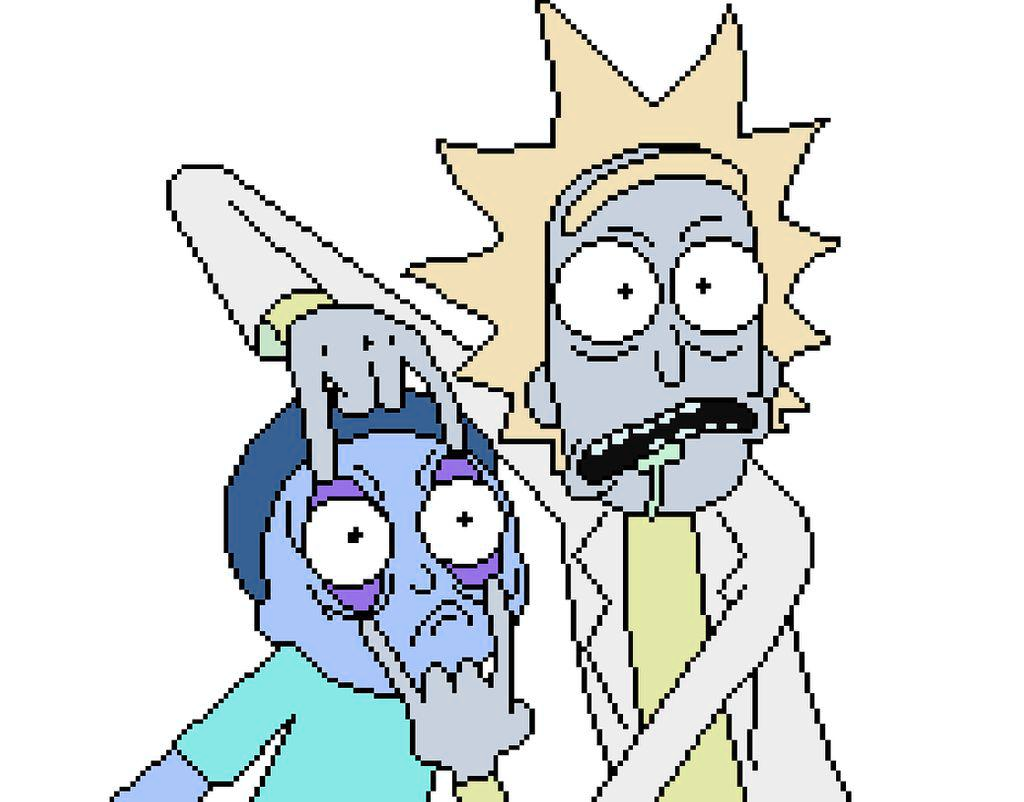

In [3]:
img = cv2.imread('rick-and-morty.jpg')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
image_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
cv2_imshow(img_rgb)

shape original : (802, 1024, 3)
shape em cinza : (802, 1024)
dtype          : uint8
faixa de valores: 0 a 255


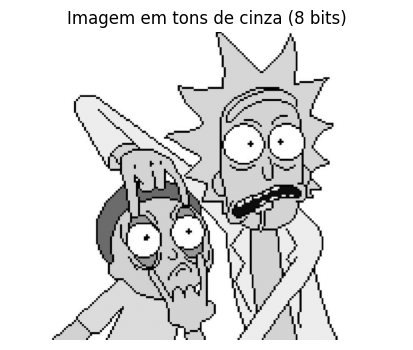

In [5]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


print('shape original :', img.shape)
print('shape em cinza :', img_gray.shape)
print('dtype          :', img_gray.dtype)
print('faixa de valores:', img_gray.min(), 'a', img_gray.max())

plt.figure(figsize=(6, 4))
plt.imshow(img_gray, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem em tons de cinza (8 bits)')
plt.axis('off')
plt.show()

In [9]:
def quantizar(img, bits):
    """Quantiza uma imagem em tons de cinza (0-255) para 2**bits níveis.
    """
    niveis = 2 ** bits
    passo = 256 / niveis

    indices = np.floor(img.astype(np.float64) / passo)
    indices = np.clip(indices, 0, niveis - 1)

    img_quantizada = indices * (255 / (niveis - 1))

    return img_quantizada.astype(np.uint8)

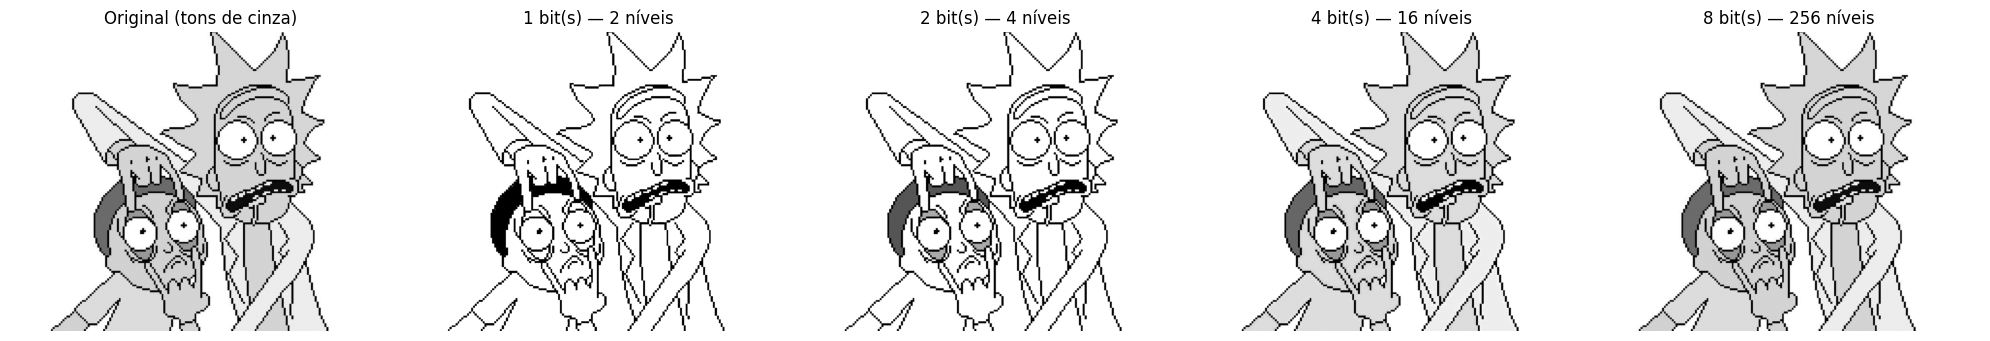

In [10]:
lista_bits = [1, 2, 4, 8]
imagens_quantizadas = [quantizar(img_gray, b) for b in lista_bits]

fig, ax = plt.subplots(1, 5, figsize=(20, 5))

ax[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original (tons de cinza)')
ax[0].axis('off')

for i, (bits, img_q) in enumerate(zip(lista_bits, imagens_quantizadas), start=1):
    ax[i].imshow(img_q, cmap='gray', vmin=0, vmax=255)
    ax[i].set_title(f'{bits} bit(s) — {2**bits} níveis')
    ax[i].axis('off')

plt.tight_layout()
plt.savefig('quantizacao.png', dpi=150, bbox_inches='tight')
plt.show()